# 12 - HGAOEnKF-MT: multiscale tendency augmentation

`hgaoenkf_plus` augments the analog ensemble's deviations with the archive's local rate of
change around each selected member, differenced over one lag. Selection draws members that
agree with the observations, so they agree with each other at the observation sites too,
and the analog covariance is flattest in exactly the directions the gain leans on hardest.
The archive's own flow never had to agree with anything, and it restores that spread out of
the time ordering selection otherwise reads only to build the exclusion band.

One lag samples one timescale. **Multiscale tendency augmentation** carries the same
construction across a band of them: first differences at seven lags from 200 to 3200 yr and
second differences at two, nine blocks of `k` rows against the one the published extension
carries.

Two scalings are what make a stack work rather than merely be larger.

- **Normalising** puts every block on the reference lag's amplitude, measured over the whole
  pool. A difference over a longer lag is larger by construction, so without it the stack is
  dominated by its longest block and carries little more than a rescaled copy of it.
- **Preserving the observation-space trace** rescales the augmented ensemble so that
  `tr(R^-1/2 H P H' R^-1/2)` matches what the members alone carried. Augmenting the
  deviations inflates the prior, and an inflated prior wants a `b_scale` below the floor of
  the grid the lanes sweep, so the estimator would be scored at an amplitude it did not ask
  for rather than on the directions it added. With the trace held, `b_scale` keeps the
  meaning it has for every other estimator and the comparison is about which directions the
  prior carries.

The blocks are centred, so they contribute nothing to the prior mean. This is a change to
the prior covariance alone.

**The stack defines the estimator; it is not tuned.** Tuning it would hand this estimator an
axis the one it extends never had, which is the same reason the evidence scale is held
rather than swept. What the grid tunes is `k`, `hybrid_w` and the flow weight, and the
weight-zero state drops the stack entirely, so the ablation is a set of rows in one grid
rather than a separate run.

In [1]:
%load_ext autoreload
%autoreload 2

# Cap BLAS threading before numpy loads, for the same reason notebook 07 does: the
# assimilation runs thousands of small eigendecompositions, a size where splitting each one
# across cores costs more than it saves. The flow stack makes the ensemble several times
# taller, so the cap matters more here, not less.
import os

for _var in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS",
             "NUMEXPR_NUM_THREADS", "VECLIB_MAXIMUM_THREADS"):
    os.environ[_var] = "1"

import json
import shutil
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube
from paleoreco.assim.analog import ANALOG_EVIDENCE
from paleoreco.assim.hgaoenkf import make_hgaoenkf
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.assim import experiments as ex

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
FIG = Path("../outputs/figures/12_hgaoenkf_mt")
FIG.mkdir(parents=True, exist_ok=True)

# Which stages this pass runs. Each clears only its own artefacts, so switching one off
# leaves the others on disk. Later stages inherit their operating point from the PPE and
# withholding grids, so those need a run in this pass or already written.
RUN_PPE = True
RUN_TRAJECTORY = True
RUN_STACK_SWEEP = True
RUN_WITHHOLDING = False

RULE = ANALOG_EVIDENCE
ESTIMATOR = ex.ESTIMATOR_HGAOENKF_MT

# The flow stack. It names the estimator rather than joining the grid, so it is passed
# whole to every driver here. The reference lag is the amplitude the other blocks are
# normalised against, which is why it must not repeat one of them.
MT_KWARGS = dict(tendency_extra_lags_yr=ex.MT_EXTRA_LAGS_YR,
                 tendency_curvature_yr=ex.MT_CURVATURE_YR,
                 tendency_normalise=True, preserve_obs_trace=True)

# The tuning grid. b_scale is swept inside every config, as it is for 3DVar. The lag axis is
# pinned to the reference lag: the stack already spans the others, and a lag repeated
# between the two would weight that timescale twice.
K_GRID = ex.K_GRID
W_GRID = ex.HYBRID_W_GRID
TENDENCY_THETA_GRID = ex.MT_THETA_GRID
TENDENCY_LAG_YR_GRID = (ex.MT_REFERENCE_LAG_YR,)
REDUNDANCY_THETA_GRID = ex.REDUNDANCY_THETA_GRID
TERM_GRIDS = dict(tendency_theta_grid=TENDENCY_THETA_GRID,
                  tendency_lag_yr_grid=TENDENCY_LAG_YR_GRID,
                  redundancy_theta_grid=REDUNDANCY_THETA_GRID)
TERM_STATES = ex.analog_term_states(TENDENCY_THETA_GRID, TENDENCY_LAG_YR_GRID,
                                    REDUNDANCY_THETA_GRID)
N_CONFIGS = len(K_GRID) * len(W_GRID) * len(TERM_STATES)

# The withholding grid is reduced rather than full. A config there costs about an hour with
# the stack on, so the full grid would run for well over a day; the axes kept are the ones
# the other lanes actually move along, plus the weight-zero state the ablation needs.
K_GRID_WH = (40, 100)
W_GRID_WH = (0.75, 1.0)
THETA_GRID_WH = (0.0, 2.0)
TERM_GRIDS_WH = dict(tendency_theta_grid=THETA_GRID_WH,
                     tendency_lag_yr_grid=TENDENCY_LAG_YR_GRID,
                     redundancy_theta_grid=REDUNDANCY_THETA_GRID)
N_CONFIGS_WH = len(K_GRID_WH) * len(W_GRID_WH) * len(ex.analog_term_states(
    THETA_GRID_WH, TENDENCY_LAG_YR_GRID, REDUNDANCY_THETA_GRID))

TERM_COLS = list(ex.TERM_KEYS)


def terms_of(cfg):
    """The extension parameters a lane's config selected, ready to pass on."""
    return {col: float(cfg["selected"][col]) for col in TERM_COLS}


def stack_for(terms):
    """The flow-stack keywords, dropped where the selected weight is zero.

    A stack needs a positive weight to be anything, and the estimator rejects one without
    it, so a lane that selects zero reports the covariance the stack was added to.
    """
    return MT_KWARGS if terms["tendency_theta"] > 0.0 else {}


def switches_for(terms):
    """The stack switches as row columns, saying what :func:`stack_for` actually passed."""
    stack = stack_for(terms)
    return {key: bool(stack.get(key, False))
            for key in ("tendency_normalise", "preserve_obs_trace")}


def describe(terms):
    """One line naming the flow stack a selected config turned on."""
    if terms["tendency_theta"] <= 0.0:
        return "no flow modes (the analog covariance the stack is added to)"
    n_first = len(ex.MT_EXTRA_LAGS_YR) + 1
    return (f"weight {terms['tendency_theta']:g} at reference lag "
            f"{terms['tendency_lag_yr']:.0f} yr; {n_first} first differences, "
            f"{len(ex.MT_CURVATURE_YR)} curvature blocks")


print(f"k {K_GRID} x hybrid_w {W_GRID} x {len(TERM_STATES)} term states "
      f"-> {N_CONFIGS} configs on the PPE lane")
print(f"withholding reduced to {N_CONFIGS_WH} configs")
print(f"flow lags {(ex.MT_REFERENCE_LAG_YR,) + ex.MT_EXTRA_LAGS_YR} yr, "
      f"curvature {ex.MT_CURVATURE_YR} yr")

k (20, 40, 60, 100) x hybrid_w (0.0, 0.25, 0.5, 0.75, 1.0) x 3 term states -> 60 configs on the PPE lane
withholding reduced to 8 configs
flow lags (400.0, 200.0, 800.0, 1200.0, 1600.0, 2400.0, 3200.0) yr, curvature (400.0, 1600.0) yr


## Prior cube, observations, and the inherited tapers

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))

D3 = OUT / "3dvar_pixel"
TAPER_KEYS = ["localization_km", "shrinkage_lambda", "alpha"]


def inherited_taper(config_name):
    """The taper the 3DVar run of one lane selected."""
    path = D3 / config_name
    if not path.exists():
        raise FileNotFoundError(
            f"{path} is missing. The analog estimators inherit their taper from the 3DVar "
            "lanes, so run those first, or pass a taper to the grid drivers directly.")
    win = json.load(open(path))["selected"]
    return {k: win[k] for k in TAPER_KEYS}


TAPER_PPE = inherited_taper("ppe_config.json")
TAPER_WH = inherited_taper("withholding_random_config.json")
print(f"cube {cube.shape}, {len(ages)} ages, {long_ppe['site'].nunique()} sites")
print(f"PPE / trajectory taper : {TAPER_PPE}")
print(f"withholding taper      : {TAPER_WH}")

cube (804, 2, 32, 64), 804 ages, 187 sites
PPE / trajectory taper : {'localization_km': 15000.0, 'shrinkage_lambda': 0.0, 'alpha': 0.25}
withholding taper      : {'localization_km': None, 'shrinkage_lambda': 0.5, 'alpha': 0.75}


## Cost check

The flow stack makes the deviation matrix roughly nine times taller, and the covariance
build is linear in its height, so a config costs several times what the published extension
costs. The weight-zero states are the cheap ones. Measure before committing: the grid is the
cost here, not the estimator.

In [3]:
COST_CHECK = False    # one config on each lane, to size the grid before committing to it

if COST_CHECK:
    tmp = OUT / "_cost_check_mt"
    shutil.rmtree(tmp, ignore_errors=True)
    for lane, fn, obs, taper, n, kw in (
        ("ppe", ex.run_hgaoenkf_ppe_grid, long_ppe, TAPER_PPE, N_CONFIGS,
         dict(n_noise=5, truth_stride=10)),
        ("withholding", ex.run_hgaoenkf_withholding_grid, long_wh, TAPER_WH, N_CONFIGS_WH,
         dict(k_folds=5)),
    ):
        t0 = time.time()
        fn(cube, ages, lats, lons, valid, obs, str(tmp / lane),
           k_grid=(60,), hybrid_w_grid=(1.0,), tendency_theta_grid=(2.0,),
           tendency_lag_yr_grid=TENDENCY_LAG_YR_GRID, selection=RULE,
           estimator=ESTIMATOR, **MT_KWARGS, **taper, **kw)
        # A one-point grid still runs the winner pass, so halve it for the per-config cost.
        per = (time.time() - t0) / 2
        print(f"{lane}: {per:.0f}s per config -> {n} configs ~ {(n + 1) * per / 60:.0f} min")
    shutil.rmtree(tmp, ignore_errors=True)
else:
    print("cost check off")

cost check off


## PPE lane

The same-model lane, and the one with the statistical power: 41 truths, each scored over
five drawn networks, four for selection and one held out. The lane parameters match the
other analog estimators' exactly, which is what lets notebook 09 pair the reconstructions
truth for truth.

In [4]:
# Files each stage owns. The PPE and withholding lanes share one metrics CSV, as they do for
# 3DVar, so clearing has to be per lane rather than per directory.
HG = OUT / f"{ESTIMATOR}_pixel"
HG_TRAJ = OUT / f"{ESTIMATOR}_pixel_trajectory"
HG_STACK = OUT / f"{ESTIMATOR}_stack"

LANE_FILES = {
    "ppe": ("ppe_config.json", "ppe_analysis.npz", "ppe_skill_vs_distance.npz"),
    "withholding_random": ("withholding_random_config.json",
                           "withholding_random_predictions.npz"),
}


def clear_lane(directory, lane):
    """Drop one lane's artefacts and its rows from the appended metrics CSV."""
    for name in LANE_FILES[lane]:
        (directory / name).unlink(missing_ok=True)
    csv = directory / "metrics.csv"
    if not csv.exists():
        return
    rest = pd.read_csv(csv)
    rest = rest[rest["lane"] != lane]
    if len(rest):
        rest.to_csv(csv, index=False)
    else:
        csv.unlink()


def last_run(path, lane_flag, lane_name):
    """The config a lane wrote, or None if that lane has never run here."""
    if path.exists():
        return json.load(open(path))
    if lane_flag:
        raise FileNotFoundError(f"{path} was expected after running the {lane_name} lane")
    print(f"[{ESTIMATOR}] no previous {lane_name} run at {path}; produce one with "
          f"RUN_{lane_name.upper()} = True")
    return None


HG.mkdir(parents=True, exist_ok=True)
if RUN_PPE:
    clear_lane(HG, "ppe")
    print(f"[{ESTIMATOR}] ppe analog grid, {N_CONFIGS} configs")
    ex.run_hgaoenkf_ppe_grid(cube, ages, lats, lons, valid, long_ppe, str(HG),
                             k_grid=K_GRID, hybrid_w_grid=W_GRID, **TERM_GRIDS,
                             selection=RULE, estimator=ESTIMATOR, **MT_KWARGS,
                             n_noise=5, truth_stride=10, progress_every=10, **TAPER_PPE)
else:
    print(f"[{ESTIMATOR}] ppe grid off; reading the last run")

PPE_CFG = last_run(HG / "ppe_config.json", RUN_PPE, "ppe")
if PPE_CFG is not None:
    K_SEL, W_SEL = PPE_CFG["selected"]["analog_k"], PPE_CFG["selected"]["hybrid_w"]
    TERMS_SEL = terms_of(PPE_CFG)
    print(f"selected on PPE: k={K_SEL}, hybrid_w={W_SEL}, "
          f"b_scale={PPE_CFG['selected']['b_scale']}")
    print(f"  stack: {describe(TERMS_SEL)}")

[hgaoenkf_mt] ppe analog grid, 60 configs
  analog-grid config 1/60 (2%, elapsed 57s, eta 3362s)
  analog-grid config 2/60 (3%, elapsed 211s, eta 6122s)
  analog-grid config 3/60 (5%, elapsed 363s, eta 6889s)
  analog-grid config 4/60 (7%, elapsed 407s, eta 5694s)
  analog-grid config 5/60 (8%, elapsed 554s, eta 6089s)
  analog-grid config 6/60 (10%, elapsed 700s, eta 6298s)
  analog-grid config 7/60 (12%, elapsed 729s, eta 5522s)
  analog-grid config 8/60 (13%, elapsed 845s, eta 5492s)
  analog-grid config 9/60 (15%, elapsed 961s, eta 5447s)
  analog-grid config 10/60 (17%, elapsed 990s, eta 4949s)
  analog-grid config 11/60 (18%, elapsed 1105s, eta 4922s)
  analog-grid config 12/60 (20%, elapsed 1220s, eta 4881s)
  analog-grid config 13/60 (22%, elapsed 1249s, eta 4517s)
  analog-grid config 14/60 (23%, elapsed 1364s, eta 4480s)
  analog-grid config 15/60 (25%, elapsed 1477s, eta 4432s)
  analog-grid config 16/60 (27%, elapsed 1514s, eta 4165s)
  analog-grid config 17/60 (28%, elapse

### Does the flow stack earn its place?

The ablation is a read of the grid rather than a separate run: the weight-zero state drops
the stack, so it is the analog covariance the stack is added to, sitting in the same metrics
CSV at the same tuned `k`, `hybrid_w` and `b_scale`.

Read the zero row first. If the grid's winner is that row then the stack bought nothing on
this lane and the estimator has reverted to the covariance it extends, which is a result and
not a failure. If a weight wins, check it wins by more than the lane resolves before
claiming it: the paired intervals here run near 0.03 on an rRMSE near 0.5, so a margin of a
few tenths of a per cent is noise. Notebook 09 carries the paired test.

In [5]:
def ablation_table(directory, lane, label):
    """Best selection-split rRMSE at each flow weight, zero included."""
    path = directory / "metrics.csv"
    if not path.exists():
        return None
    m = pd.read_csv(path)
    sel = m[(m.lane == lane) & (m.split == "selection") & (m.method == label)
            & (m.channel == "pooled") & (m.do_event == "all") & (m.metric == "rrmse")]
    if sel.empty:
        return None
    rows = []
    for theta, group in sel.groupby("tendency_theta"):
        best = group.loc[group["value"].idxmin()]
        rows.append({"flow weight": float(theta),
                     "selection rrmse": float(best["value"]),
                     "k": int(best["analog_k"]), "hybrid_w": float(best["hybrid_w"]),
                     "b_scale": float(best["b_scale"])})
    tab = pd.DataFrame(rows).set_index("flow weight").sort_index()
    if 0.0 in tab.index:
        base = tab.loc[0.0, "selection rrmse"]
        tab["gain vs no flow"] = 100 * (base - tab["selection rrmse"]) / base
    return tab


PPE_ABL = ablation_table(HG, "ppe", ex.method_label(ESTIMATOR))
if PPE_ABL is None:
    print("no PPE rows yet")
else:
    print("PPE selection split, best over (k, hybrid_w, b_scale) at each flow weight;\n"
          "weight 0 is the analog covariance without the stack:")
    display(PPE_ABL.round({"selection rrmse": 4, "hybrid_w": 2, "b_scale": 2,
                           "gain vs no flow": 2}))

PPE selection split, best over (k, hybrid_w, b_scale) at each flow weight;
weight 0 is the analog covariance without the stack:


,selection rrmse,k,hybrid_w,b_scale,gain vs no flow
flow weight,,,,,
0.0,0.5240,60,0.75,5.0,0.00
1.0,0.4992,60,1.00,10.0,4.72
2.0,0.4960,60,1.00,10.0,5.33


### The selection surface

Error and amplitude at the same operating point, so a flat reconstruction cannot hide behind
an rRMSE that barely moves. The stack widens the analog covariance, so a lower rRMSE bought
by a flatter field would show in the amplitude panel first.

no flow modes: selection-split RRMSE at each (k, hybrid_w), minimised over b_scale:


hybrid_w,0.00,0.25,0.50,0.75,1.00
analog_k,,,,,
20.0,0.5439,0.5361,0.5282,0.5290,0.5389
40.0,0.5436,0.5348,0.5260,0.5242,0.5306
60.0,0.5440,0.5347,0.5269,0.5240,0.5281
100.0,0.5455,0.5358,0.5288,0.5243,0.5253


flow weight 1: selection-split RRMSE at each (k, hybrid_w), minimised over b_scale:


hybrid_w,0.00,0.25,0.50,0.75,1.00
analog_k,,,,,
20.0,0.5439,0.5353,0.5219,0.5107,0.5031
40.0,0.5436,0.5337,0.5198,0.5085,0.4995
60.0,0.5440,0.5332,0.5191,0.5080,0.4992
100.0,0.5455,0.5336,0.5188,0.5071,0.4995


flow weight 2: selection-split RRMSE at each (k, hybrid_w), minimised over b_scale:


hybrid_w,0.00,0.25,0.50,0.75,1.00
analog_k,,,,,
20.0,0.5439,0.5351,0.5212,0.5094,0.5023
40.0,0.5436,0.5333,0.5185,0.5062,0.4975
60.0,0.5440,0.5326,0.5172,0.5053,0.4960
100.0,0.5455,0.5329,0.5163,0.5041,0.4964


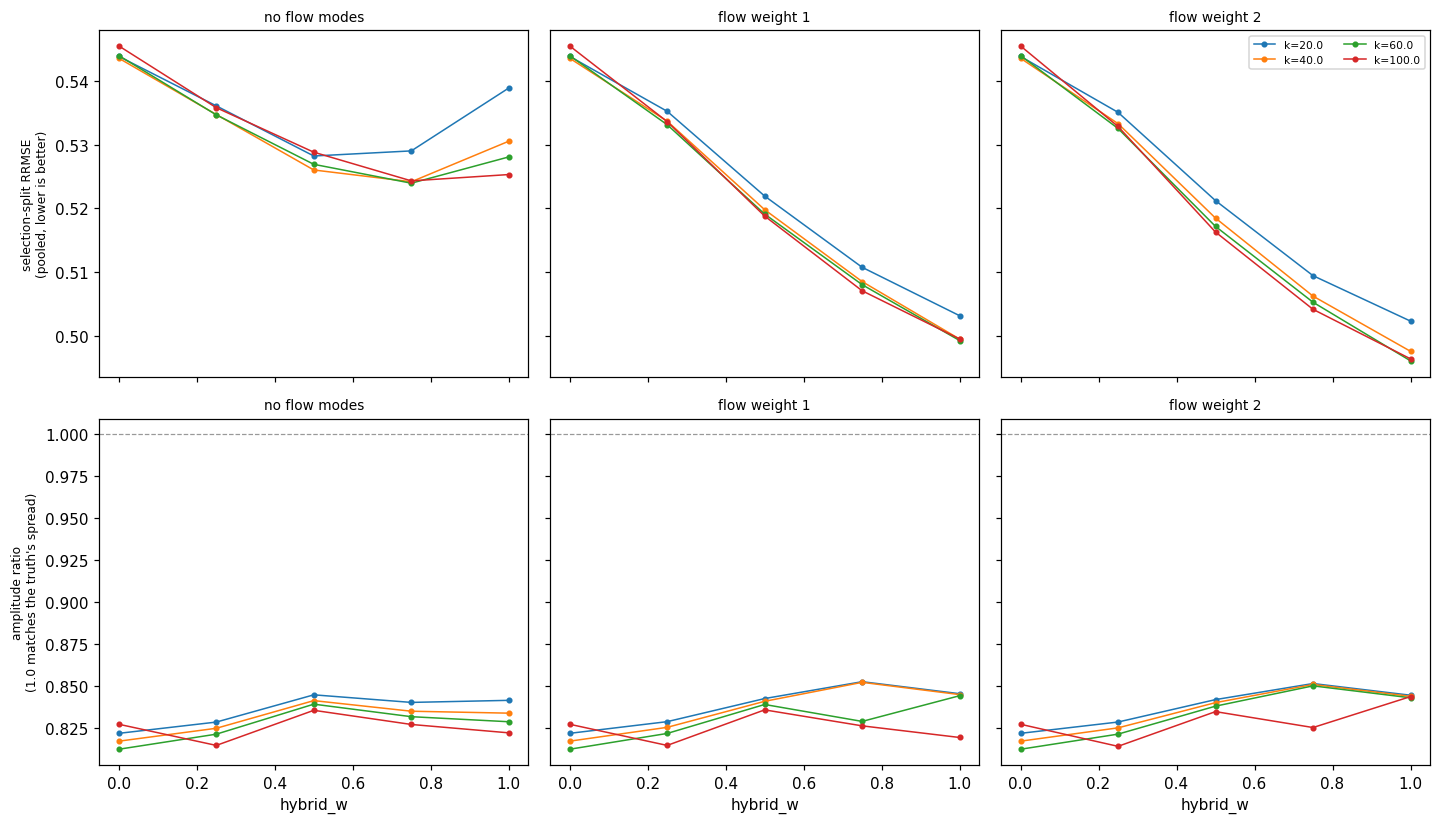

In [6]:
def ppe_surface(directory, label, metric, theta):
    """Selection-split ``metric`` at each (k, hybrid_w), read at the rRMSE-optimal b_scale."""
    m = pd.read_csv(directory / "metrics.csv")
    sel = m[(m.lane == "ppe") & (m.split == "selection") & (m.method == label)
            & (m.channel == "pooled") & (m.do_event == "all")]
    sel = sel[np.isclose(sel.tendency_theta.to_numpy(dtype=float), float(theta))]
    rrmse = sel[sel.metric == "rrmse"]
    keys = ["analog_k", "hybrid_w", "b_scale"]
    best = rrmse.loc[rrmse.groupby(["analog_k", "hybrid_w"])["value"].idxmin(), keys]
    at_best = sel[sel.metric == metric].merge(best, on=keys)
    return at_best.groupby(["analog_k", "hybrid_w"])["value"].min().unstack()


if PPE_CFG is None:
    raise RuntimeError("the surface reads the PPE grid; run it first")

label = ex.method_label(ESTIMATOR)
STATES = [(0.0, "no flow modes")] + [(t, f"flow weight {t:g}")
                                     for t in TENDENCY_THETA_GRID if t > 0]
PANELS = (("rrmse", "selection-split RRMSE\n(pooled, lower is better)"),
          ("amplitude", "amplitude ratio\n(1.0 matches the truth's spread)"))

fig, axes = plt.subplots(len(PANELS), len(STATES), squeeze=False, sharex=True, sharey="row",
                         figsize=(4.4 * len(STATES), 3.8 * len(PANELS)))
for row, (metric, ylabel) in enumerate(PANELS):
    for col, (theta, title) in enumerate(STATES):
        ax = axes[row, col]
        surface = ppe_surface(HG, label, metric, theta)
        if metric == "rrmse":
            print(f"{title}: selection-split RRMSE at each (k, hybrid_w), "
                  "minimised over b_scale:")
            display(surface.round(4))
        for k, values in surface.iterrows():
            ax.plot(values.index, values.to_numpy(), marker="o", ms=3, lw=1,
                    label=f"k={k}")
        ax.set_title(title, fontsize=9)
        if row == len(PANELS) - 1:
            ax.set_xlabel("hybrid_w")
        if col == 0:
            ax.set_ylabel(ylabel, fontsize=8)
        if metric == "amplitude":
            ax.axhline(1.0, color="0.6", lw=0.8, ls="--")
axes[0, -1].legend(fontsize=7, ncol=2)
fig.tight_layout()
fig.savefig(FIG / "ppe_selection_surface.png", bbox_inches="tight")
plt.show()

## Trajectory lane

A consecutive run of states scored by timescale, at the PPE-selected operating point. It
grids nothing of its own beyond `b_scale`, so it is the closest thing here to a held-out
lane, and it is the one where the flow stack's timescale content should show most directly.

In [7]:
if RUN_TRAJECTORY and PPE_CFG is None:
    raise RuntimeError("the trajectory lane runs at the PPE-selected operating point; "
                       "run the PPE grid first")

if RUN_TRAJECTORY:
    shutil.rmtree(HG_TRAJ, ignore_errors=True)
    print(f"[{ESTIMATOR}] trajectory at k={K_SEL}, hybrid_w={W_SEL}; "
          f"{describe(TERMS_SEL)}")
    ex.run_trajectory(
        cube, ages, lats, lons, valid, long_ppe, str(HG_TRAJ),
        make_method=make_hgaoenkf(cube, ages, lats, lons, k=K_SEL, hybrid_w=W_SEL,
                                  selection=RULE, **TERMS_SEL, **stack_for(TERMS_SEL)),
        estimator=ESTIMATOR,
        method_cols=ex.analog_cols(K_SEL, W_SEL, **TERMS_SEL, **switches_for(TERMS_SEL)),
        temporal_modes=ex.TEMPORAL_MODES, progress_every=50, **TAPER_PPE)
else:
    print(f"[{ESTIMATOR}] trajectory lane off; reading the last run")

TRAJ_CFG = last_run(HG_TRAJ / "trajectory_config.json", RUN_TRAJECTORY, "trajectory")
if TRAJ_CFG is not None:
    print(f"  scored {TRAJ_CFG['n_covered_ages']} ages, "
          f"skipped {TRAJ_CFG['n_skipped_ages']}")
    print(f"  selection {TRAJ_CFG['selection_ages']} yr BP, "
          f"test {TRAJ_CFG['test_ages']} yr BP")
    print("  b_scale* per method:", TRAJ_CFG["selected_b_scale_by_method"])

[hgaoenkf_mt] trajectory at k=60, hybrid_w=1.0; weight 2 at reference lag 400 yr; 7 first differences, 2 curvature blocks
  trajectory age 87/402 (22%, elapsed 61s, eta 221s)
  trajectory age 137/402 (34%, elapsed 132s, eta 254s)
  trajectory age 187/402 (47%, elapsed 195s, eta 224s)
  trajectory age 237/402 (59%, elapsed 256s, eta 178s)
  trajectory age 287/402 (71%, elapsed 323s, eta 129s)
  trajectory age 337/402 (84%, elapsed 385s, eta 74s)
  trajectory age 387/402 (96%, elapsed 449s, eta 17s)
  scored 365 ages, skipped 37
  selection [30025, 34550] yr BP, test [34575, 39125] yr BP
  b_scale* per method: {'hgaoenkf_mt': 0.5, 'hgaoenkf_mt_temporal_add': 1.0, 'hgaoenkf_mt_temporal_deflate': 1.0}


analog-set overlap between neighbouring analyses (25 yr apart):
  mean 0.418, median 0.417, 10th pct 0.233
  overlap beyond 1000 yr: 0.140 (chance = 0.149)


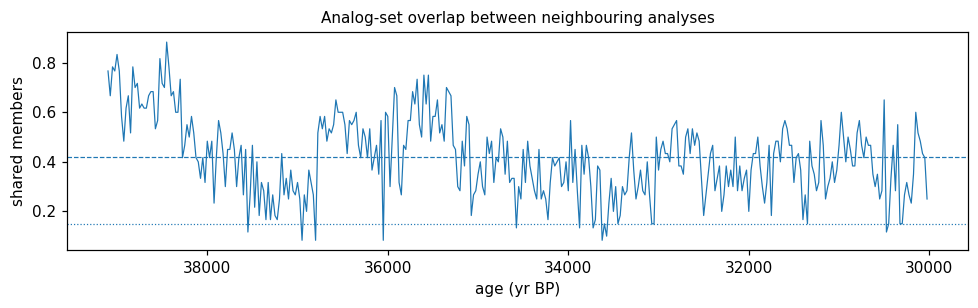


Selection draws the members; the flow blocks are built around whichever members it drew, so this reads the same structure it does for the estimator without them. What the stack changes is how many directions each drawn member contributes, not which members are drawn.


In [8]:
if TRAJ_CFG is None:
    raise RuntimeError("no trajectory run to read")

zt = np.load(HG_TRAJ / "trajectory_analysis.npz")
idx = zt["analog_index"]
step_yr = float(zt["step_yr"])
sets = [set(row.tolist()) for row in idx]
k = idx.shape[1]
chance = k / TRAJ_CFG["prior_meta"]["n_prior_ages"]

adjacent = np.array([len(sets[i] & sets[i + 1]) / k for i in range(len(sets) - 1)])
far = np.array([len(sets[i] & sets[j]) / k
                for i in range(0, len(sets), 17) for j in range(0, len(sets), 19)
                if abs(i - j) * step_yr > 1000])

print(f"analog-set overlap between neighbouring analyses ({step_yr:.0f} yr apart):")
print(f"  mean {adjacent.mean():.3f}, median {np.median(adjacent):.3f}, "
      f"10th pct {np.percentile(adjacent, 10):.3f}")
print(f"  overlap beyond 1000 yr: {far.mean():.3f} (chance = {chance:.3f})")

fig, ax = plt.subplots(figsize=(9, 2.9))
ax.plot(zt["ages"][:-1], adjacent, lw=0.8, color="C0")
ax.axhline(adjacent.mean(), color="C0", lw=0.8, ls="--")
ax.axhline(chance, color="C0", lw=0.8, ls=":")
ax.set_xlabel("age (yr BP)")
ax.set_ylabel("shared members")
ax.set_title("Analog-set overlap between neighbouring analyses", fontsize=10)
ax.invert_xaxis()
fig.tight_layout()
fig.savefig(FIG / "analog_set_stability.png", bbox_inches="tight")
plt.show()

print("\nSelection draws the members; the flow blocks are built around whichever members "
      "it drew, so this reads the same structure it does for the estimator without them. "
      "What the stack changes is how many directions each drawn member contributes, not "
      "which members are drawn.")

## Withholding lane

Real pollen, tuned independently of the PPE lane. Its prior spans every age including the
one being reconstructed, so `exclude_yr` drops a band around the target from the analog pool.
That band also bounds the flow blocks: a neighbour a lag away can sit inside the band while
the member itself is eligible, and the estimator drops those rows per block rather than
reaching back into what the band excludes. Long lags therefore lose more rows than short
ones, which is the intended behaviour and not a defect.

This grid is reduced. A config here costs about an hour with the stack on, so the full grid
would run for well over a day.

In [9]:
EXCLUDE_YR = ex.EXCLUDE_YR

if RUN_WITHHOLDING:
    clear_lane(HG, "withholding_random")
    print(f"[{ESTIMATOR}] withholding analog grid, {N_CONFIGS_WH} configs, "
          f"exclusion band {EXCLUDE_YR:.0f} yr")
    ex.run_hgaoenkf_withholding_grid(
        cube, ages, lats, lons, valid, long_wh, str(HG),
        k_grid=K_GRID_WH, hybrid_w_grid=W_GRID_WH, **TERM_GRIDS_WH,
        exclude_yr=EXCLUDE_YR, selection=RULE, estimator=ESTIMATOR, **MT_KWARGS,
        report_temporal_modes=ex.TEMPORAL_MODES,
        k_folds=5, progress_every=1, **TAPER_WH)
else:
    print(f"[{ESTIMATOR}] withholding grid off; reading the last run")

WH_CFG = last_run(HG / "withholding_random_config.json", RUN_WITHHOLDING, "withholding")
if WH_CFG is not None:
    K_WH, W_WH = WH_CFG["selected"]["analog_k"], WH_CFG["selected"]["hybrid_w"]
    TERMS_WH = terms_of(WH_CFG)
    print(f"selected on withholding: k={K_WH}, hybrid_w={W_WH}, "
          f"b_scale={WH_CFG['selected']['b_scale']}")
    print(f"  stack: {describe(TERMS_WH)}")
    print(f"selected on PPE        : k={K_SEL}, hybrid_w={W_SEL}")
    print(f"  stack: {describe(TERMS_SEL)}")
    if (K_WH, W_WH, TERMS_WH) != (K_SEL, W_SEL, TERMS_SEL):
        print("  the two lanes disagree. They measure different things: the PPE lane "
              "scores a model state drawn from the same distribution as the prior, the "
              "withholding lane scores real pollen and is the only one whose truth is "
              "independent of the model. Report the gap rather than averaging it. This "
              "lane's whole surface is narrow, so read the disagreement as weak evidence.")

    WH_ABL = ablation_table(HG, "withholding_random",
                            ex.method_label(ESTIMATOR, ex.TEMPORAL_DEFLATE))
    if WH_ABL is not None:
        print("\nWithholding selection split, by flow weight:")
        display(WH_ABL.round({"selection rrmse": 4, "hybrid_w": 2, "b_scale": 2,
                              "gain vs no flow": 2}))

[hgaoenkf_mt] withholding grid off; reading the last run
[hgaoenkf_mt] no previous withholding run at ../outputs/da/hgaoenkf_mt_pixel/withholding_random_config.json; produce one with RUN_WITHHOLDING = True


## How much the choice of timescales matters

The stack is held rather than tuned, so this pass measures what holding it costs. Every
entry runs at the PPE-selected operating point and at the same weight and the same
observation-space trace, so the only difference between them is which timescales the blocks
sample.

Read `1lag` as the reference rather than as the published extension: it carries one first
difference, as that estimator does, but under the same trace preservation as the rest of the
sweep, so it isolates the set of timescales and not the two scalings.

If the optimum is not at the shipped stack then the reported margin is conservative, since
the estimator is being scored at a stack it did not choose. That is the honest way to carry
an untuned choice, and it is the claim this sweep supports.

In [10]:
if RUN_STACK_SWEEP and PPE_CFG is None:
    raise RuntimeError("the stack sweep runs at the PPE-selected operating point; "
                       "run the PPE grid first")

if RUN_STACK_SWEEP and TERMS_SEL["tendency_theta"] <= 0.0:
    print(f"[{ESTIMATOR}] the PPE grid selected no flow modes, so there is no stack to "
          "vary; skipping the sweep")
elif RUN_STACK_SWEEP:
    shutil.rmtree(HG_STACK, ignore_errors=True)
    print(f"[{ESTIMATOR}] stack sweep at k={K_SEL}, hybrid_w={W_SEL}, "
          f"weight {TERMS_SEL['tendency_theta']:g}")
    t0 = time.time()
    for name, (extra, curvature) in ex.MT_STACKS.items():
        ex.run_ppe(cube, ages, lats, lons, valid, long_ppe, str(HG_STACK),
                   make_method=make_hgaoenkf(
                       cube, ages, lats, lons, k=K_SEL, hybrid_w=W_SEL, selection=RULE,
                       **TERMS_SEL, tendency_extra_lags_yr=extra,
                       tendency_curvature_yr=curvature,
                       tendency_normalise=True, preserve_obs_trace=True),
                   estimator=ex.mt_stack_estimator(name),
                   method_cols=ex.analog_cols(K_SEL, W_SEL, **TERMS_SEL,
                                              tendency_normalise=True,
                                              preserve_obs_trace=True),
                   n_noise=5, truth_stride=10, **TAPER_PPE)
        print(f"  {name} done (elapsed {time.time() - t0:.0f}s)", flush=True)
else:
    print(f"[{ESTIMATOR}] stack sweep off; reading the last run")

if not (HG_STACK / "metrics.csv").exists():
    print(f"[{ESTIMATOR}] no stack sweep on disk")
else:
    M_S = pd.read_csv(HG_STACK / "metrics.csv")
    rows = []
    for name in ex.MT_STACKS:
        tag = ex.method_label(ex.mt_stack_estimator(name))
        sub = M_S[(M_S.method == tag) & (M_S.channel == "pooled")
                  & (M_S.do_event == "all") & (M_S.metric == "rrmse")]
        sel = sub[sub.split == "selection"]
        if sel.empty:
            continue
        b = float(sel.loc[sel["value"].idxmin(), "b_scale"])
        test = sub[(sub.split == "test") & np.isclose(sub.b_scale, b)]
        rows.append({"stack": name, "n first diffs": len(ex.MT_STACKS[name][0]) + 1,
                     "n curvature": len(ex.MT_STACKS[name][1]),
                     "selection rrmse": float(sel["value"].min()),
                     "test rrmse": float(test["value"].iloc[0]) if len(test) else np.nan,
                     "b*": b})
    stack_tab = pd.DataFrame(rows).set_index("stack")
    print("PPE lane against the set of timescales, at the selected operating point:")
    display(stack_tab.round(4))

[hgaoenkf_mt] stack sweep at k=60, hybrid_w=1.0, weight 2
  1lag done (elapsed 74s)
  3lag done (elapsed 205s)
  7lag done (elapsed 524s)
  7lag_curv done (elapsed 961s)
PPE lane against the set of timescales, at the selected operating point:


,n first diffs,n curvature,selection rrmse,test rrmse,b*
stack,,,,,
1lag,1,0,0.5055,0.5115,10.0
3lag,3,0,0.5005,0.5027,10.0
7lag,7,0,0.4970,0.4957,10.0
7lag_curv,7,2,0.4960,0.4943,10.0


## Reading

- **Start with the ablation table.** The weight-zero row is the analog covariance the stack
  is added to, so the whole case for the mechanism is the margin between that row and the
  best weighted one. A lane that finds the stack worthless reports the covariance without
  it, which is a result and nothing is lost by saying so.
- **The two lanes may select different states.** That is expected and is not evidence of
  anything on its own: the withholding surface is narrow enough that its argmin is close to
  arbitrary. Report the selected point per lane; do not read a story into the gap.
- **The stack should lower the selected `b_scale` far less than an unnormalised one would.**
  Preserving the observation-space trace is what holds `b_scale` comparable across
  estimators. A selected `b_scale` at the floor of the grid means the trace preservation is
  not doing its job and the comparison is about amplitude rather than direction.
- **Watch the amplitude panel.** The stack widens the analog covariance, so a lower rRMSE
  bought by a flatter field would show there first.
- **The trajectory lane is the one nothing was tuned on.** Its operating point is inherited
  from the PPE grid, so it is where the per-channel and per-timescale picture in notebook 09
  is worth most, and it is where a stack spanning several timescales has the clearest reason
  to help.
- **Expect the calibration metrics to move.** The flow blocks are part of the ensemble the
  square-root update reduces, so the posterior spread changes. Calibration is not what the
  stack was added for; report the change rather than claiming it.
- The head-to-head against the baseline and against `hgaoenkf_plus`, the timescale curves,
  the staleness ladder and the paired intervals are all in notebook 09.